# Weight Decay Study

**Hypothesis:** `J_conv` grows without bound because `weight_decay=0`. A non-zero decay creates a restoring force `−wd·J` that stabilises the norm at a finite equilibrium, which should:
1. Stop `‖J_conv‖` from diverging
2. Make the output margin more stable (less 0/100% oscillation)
3. Potentially improve catastrophic forgetting behaviour

**Sweep:** `weight_decay ∈ [0.0, 0.001, 0.01, 0.1]`  
**Fixed:** `threshold=1.0, lr=0.5, mask_prob=0.0, momentum=0.0`  
**Data:** CIFAR-10 single image

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import equinox as eqx
import jax.tree_util as jtu
import optax

from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer
from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator
from darnax.datasets.classification.cifar10 import Cifar10

RESULTS_DIR = Path("results/weight_decay_study")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"JAX devices: {jax.devices()}")
print(f"Results → {RESULTS_DIR.resolve()}")

JAX devices: [CpuDevice(id=0)]
Results → /Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/experiments/results/weight_decay_study


## Data

In [18]:
data = Cifar10(batch_size=32, linear_projection=None, label_mode="pm1", x_transform="identity")
key = jax.random.PRNGKey(0)
key, dk = jax.random.split(key)
data.build(key=dk)

it = iter(data)
x_A, y_A = next(it)
next(it)
x_B, y_B = next(it)

if x_A.ndim == 2: x_A = x_A.reshape(x_A.shape[0], 32, 32, 3)
if x_B.ndim == 2: x_B = x_B.reshape(x_B.shape[0], 32, 32, 3)

x_A = (x_A - x_A.mean()) / x_A.std()
x_B = (x_B - x_B.mean()) / x_B.std()

x_A1, y_A1 = x_A[0:1], y_A[0:1]
x_B1, y_B1 = x_B[0:1], y_B[0:1]

print(f"Single image A: {x_A1.shape}  label: {np.argmax(np.array(y_A1))}")
print(f"Single image B: {x_B1.shape}  label: {np.argmax(np.array(y_B1))}")

Single image A: (1, 32, 32, 3)  label: 3
Single image B: (1, 32, 32, 3)  label: 4


## Architecture & helpers

In [13]:
# ── Fixed hyperparameters ───────────────────────────────────────────────
FIX_THR      = 1.0
FIX_LR       = 0.5
FIX_MASK     = 0.2
FIX_MO       = 0.5
N_CHANNELS   = 64
J_D          = 0.9
N_STEPS      = 150     # enough to reach norm plateau
# Effective decay per step = lr × wd × (1/sqrt(N×Ho×Wo)) = 0.5 × wd × (1/32)
# So wd=1  → ~0.016×J/step,  wd=10 → ~0.16×J/step,  wd=100 → ~1.6×J/step
WD_VALUES    = [0.0, 1.0, 10.0, 100.0]

# Forgetting protocol
N_PHASE_A    = 40
N_PHASE_B    = 40


def build_model(seed=0, threshold=FIX_THR, mask_prob=FIX_MASK, momentum=FIX_MO,
                weight_decay=0.0, n_channels=N_CHANNELS, j_d=J_D):
    keys = jax.random.split(jax.random.key(seed), 5)
    lmap = LayerMap.from_dict({
        1: {
            0: Conv2D(in_channels=3, out_channels=n_channels, kernel_size=7,
                      threshold=threshold, strength=1.0, key=keys[0], padding_mode="constant"),
            1: Conv2DRecurrentDiscrete(channels=n_channels, kernel_size=7, groups=n_channels,
                                       j_d=j_d, threshold=threshold,
                                       padding_mode="constant", key=keys[1],
                                       lr=1.0, weight_decay=weight_decay),  # ← HERE
            2: GlobalUnpooling(strength=1.0, axis=(1, 2)),
        },
        2: {
            1: GlobalMajorityPooling(strength=1.0, axis=(1, 2)),
            2: RecurrentDiscrete(features=n_channels, j_d=j_d, threshold=threshold, key=keys[2]),
            3: FrozenRescaledFullyConnected(in_features=10, out_features=n_channels,
                                            strength=1.0, threshold=0.0, key=keys[3]),
        },
        3: {
            2: FullyConnected(in_features=n_channels, out_features=10,
                              strength=1.0, threshold=threshold, key=keys[4]),
            3: OutputLayer(),
        },
    })
    state = SequentialState([(32, 32, 3), (32, 32, n_channels), (n_channels,), (10,)])
    orch  = SequentialOrchestrator(layers=lmap, field_momentum=momentum, mask_prob=mask_prob)
    return state, orch


def build_opt(orch, lr=FIX_LR):
    params, _ = eqx.partition(orch, eqx.is_inexact_array)
    labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)
    def like(tree, v): return jtu.tree_map(lambda _: v, tree, is_leaf=eqx.is_array)
    trainable = {(1,0): "w", (1,1): "w", (2,2): "w", (3,2): "w"}
    for (i, j), lbl in trainable.items():
        labels = eqx.tree_at(lambda m, _i=i, _j=j: m.lmap[_i][_j], labels,
                             replace=like(params.lmap[i][j], lbl))
    transforms = {"default": optax.sgd(0.0), "w": optax.sgd(lr)}
    opt = optax.multi_transform(transforms, labels)
    return opt, opt.init(eqx.filter(orch, eqx.is_inexact_array))


def run_dynamics(orch, state, rng, n_warmup=1, n_clamped=5, n_free=5):
    for _ in range(n_warmup):
        state, rng = orch.step(state, rng=rng, filter_messages="inference")
    for _ in range(n_clamped):
        state, rng = orch.step(state, rng=rng, filter_messages="all")
    for _ in range(n_free):
        state, rng = orch.step(state, rng=rng, filter_messages="inference")
    return state, rng


def update_weights(orch, state, rng, opt, opt_st):
    rng, upd_rng = jax.random.split(rng)
    grads = orch.backward(state, rng=upd_rng)
    g_filt = eqx.filter(grads, eqx.is_inexact_array)
    p_filt = eqx.filter(orch,  eqx.is_inexact_array)
    upds, opt_st = opt.update(g_filt, opt_st, params=p_filt)
    orch = eqx.apply_updates(orch, upds)
    return orch, opt_st, rng


def get_accuracy(orch, state_final, y_true, rng):
    rng, pr = jax.random.split(rng)
    pred_st, _ = orch.predict(state_final, pr)
    pred = np.argmax(np.array(pred_st.states[-1]), axis=-1)
    true = np.argmax(np.array(y_true), axis=-1)
    return float(np.mean(pred == true)) * 100.0, rng


def get_soft_scores(orch, state_final, y_true, rng):
    rng, pr = jax.random.split(rng)
    pred_st, _ = orch.predict(state_final, pr)
    out = np.array(pred_st.states[-1])
    true_idx = np.argmax(np.array(y_true), axis=-1)
    correct_logit = out[np.arange(len(true_idx)), true_idx]
    mask = np.ones_like(out, dtype=bool)
    mask[np.arange(len(true_idx)), true_idx] = False
    wrong_max = out[mask].reshape(len(true_idx), -1).max(axis=-1)
    return float(correct_logit.mean()), float((correct_logit - wrong_max).mean()), rng


def weight_norms(orch):
    norms = {}
    for (i, j), name in [((1,0),"w_in"), ((1,1),"j_conv"), ((2,2),"j_fc"), ((3,2),"w_out")]:
        w = eqx.filter(orch.lmap[i][j], eqx.is_inexact_array)
        flat = jnp.concatenate([l.ravel() for l in jax.tree.leaves(w)])
        norms[name] = float(jnp.linalg.norm(flat))
    return norms


# Show effective decay rates
print(f"Config: thr={FIX_THR}, lr={FIX_LR}, mask={FIX_MASK}, mo={FIX_MO}")
decay_scale = 1.0 / (32)   # 1/sqrt(1×32×32)=1/32 but sgd multiplies lr
print(f"\nEffective decay per step = lr × wd × (1/sqrt(N×Ho×Wo)) = 0.5 × wd × {decay_scale:.4f}")
for wd in WD_VALUES:
    eff = FIX_LR * wd * decay_scale
    print(f"  wd={wd:<6} → effective decay/step ≈ {eff:.4f} × ‖J‖")
print(f"\nN_STEPS={N_STEPS}  |  Forgetting: A={N_PHASE_A} → B={N_PHASE_B}")
print("Helpers defined ✓")


Config: thr=1.0, lr=0.5, mask=0.2, mo=0.5

Effective decay per step = lr × wd × (1/sqrt(N×Ho×Wo)) = 0.5 × wd × 0.0312
  wd=0.0    → effective decay/step ≈ 0.0000 × ‖J‖
  wd=1.0    → effective decay/step ≈ 0.0156 × ‖J‖
  wd=10.0   → effective decay/step ≈ 0.1562 × ‖J‖
  wd=100.0  → effective decay/step ≈ 1.5625 × ‖J‖

N_STEPS=150  |  Forgetting: A=40 → B=40
Helpers defined ✓


---
## Experiment 1 — Weight norm evolution vs weight decay

Does `‖J_conv‖` saturate when `weight_decay > 0`?

In [14]:
norm_results = {}   # wd → list of norm dicts

for wd in WD_VALUES:
    st, orch = build_model(seed=0, weight_decay=wd)
    opt, opt_st = build_opt(orch)
    rng = jax.random.PRNGKey(42)
    norms_over_time = []

    for step in range(N_STEPS + 1):
        s0 = st.init(x_A1, y_A1)
        rng, dr = jax.random.split(rng)
        sf, _ = run_dynamics(orch, s0, dr)
        norms_over_time.append(weight_norms(orch))
        if step < N_STEPS:
            orch, opt_st, rng = update_weights(orch, sf, rng, opt, opt_st)

    norm_results[wd] = norms_over_time
    final = norms_over_time[-1]
    print(f"wd={wd:<6}  j_conv: {norms_over_time[0]['j_conv']:.1f} → {final['j_conv']:.1f}  "
          f"| w_in: {final['w_in']:.1f}  w_out: {final['w_out']:.1f}")

print("\nNorm sweep done ✓")

wd=0.0     j_conv: 56.5 → 34975.7  | w_in: 2824.3  w_out: 7.9
wd=1.0     j_conv: 56.5 → 15653.3  | w_in: 1627.0  w_out: 7.1
wd=10.0    j_conv: 57.3 → 1770.9  | w_in: 250.6  w_out: 6.3
wd=100.0   j_conv: 114.8 → 114.6  | w_in: 91.8  w_out: 5.8

Norm sweep done ✓


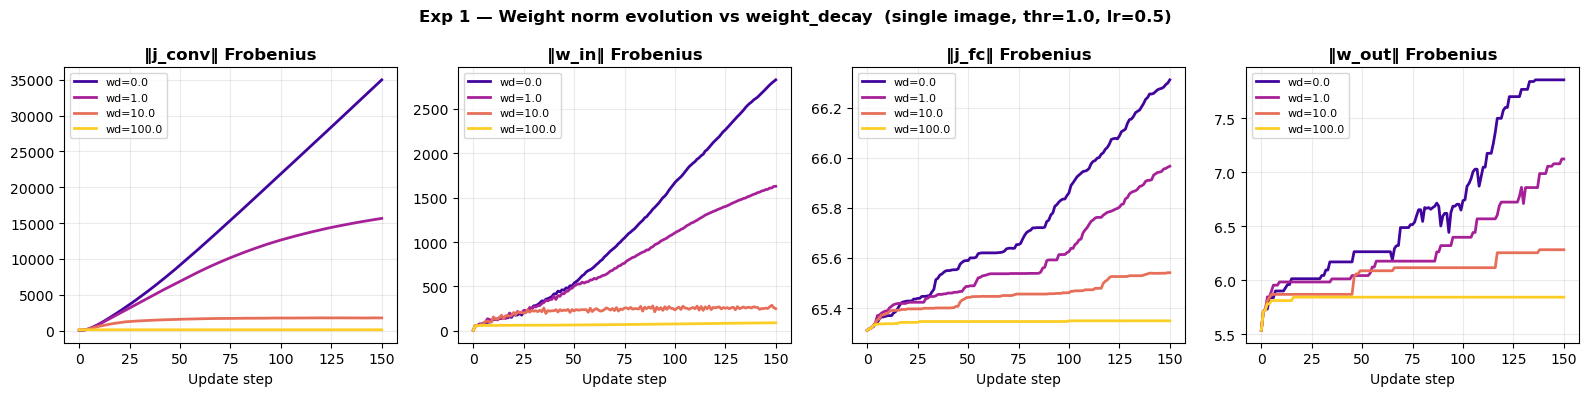

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(WD_VALUES)))
layer_names = ["j_conv", "w_in", "j_fc", "w_out"]

for ax, lname in zip(axes, layer_names):
    for ci, wd in enumerate(WD_VALUES):
        vals = [n[lname] for n in norm_results[wd]]
        ax.plot(vals, color=colors[ci], lw=2, label=f"wd={wd}")
    ax.set_title(f"‖{lname}‖ Frobenius", fontweight="bold")
    ax.set_xlabel("Update step")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("Exp 1 — Weight norm evolution vs weight_decay  (single image, thr=1.0, lr=0.5)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp1_norms.png", dpi=120)
plt.show()

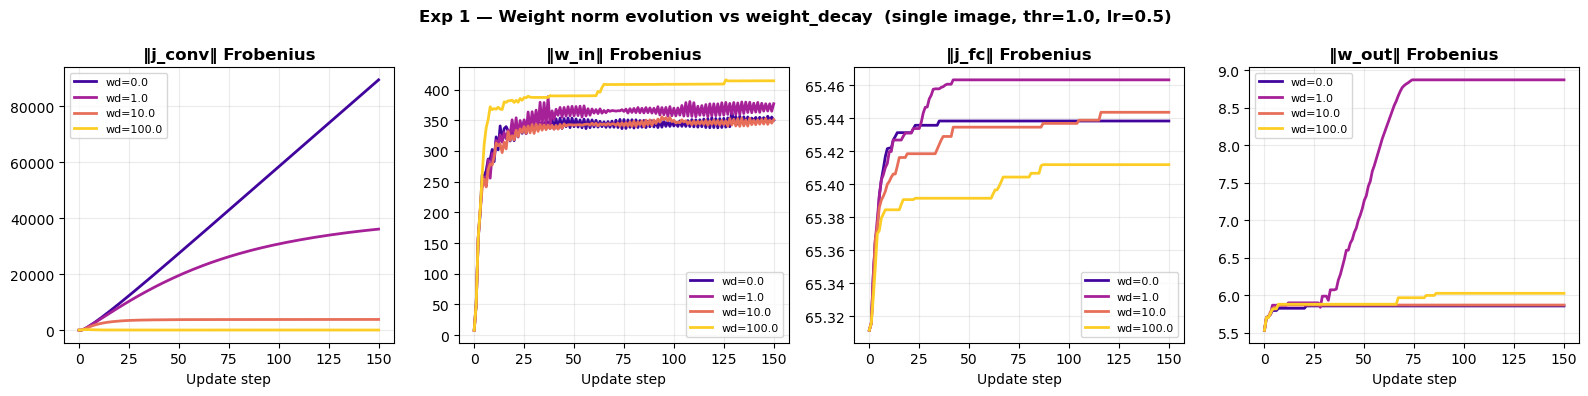

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(WD_VALUES)))
layer_names = ["j_conv", "w_in", "j_fc", "w_out"]

for ax, lname in zip(axes, layer_names):
    for ci, wd in enumerate(WD_VALUES):
        vals = [n[lname] for n in norm_results[wd]]
        ax.plot(vals, color=colors[ci], lw=2, label=f"wd={wd}")
    ax.set_title(f"‖{lname}‖ Frobenius", fontweight="bold")
    ax.set_xlabel("Update step")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("Exp 1 — Weight norm evolution vs weight_decay  (single image, thr=1.0, lr=0.5)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp1_norms.png", dpi=120)
plt.show()

---
## Experiment 2 — Memorization confidence vs weight decay

Does a stable norm lead to a stable, high-confidence output margin?

In [8]:
mem_results = {}   # wd → {accs, logits, margins}

for wd in WD_VALUES:
    st, orch = build_model(seed=0, weight_decay=wd)
    opt, opt_st = build_opt(orch)
    rng = jax.random.PRNGKey(42)
    accs, logits, margins = [], [], []

    for step in range(N_STEPS + 1):
        s0 = st.init(x_A1, y_A1)
        rng, dr = jax.random.split(rng)
        sf, _ = run_dynamics(orch, s0, dr)
        acc, rng = get_accuracy(orch, sf, y_A1, rng)
        cl, mg, rng = get_soft_scores(orch, sf, y_A1, rng)
        accs.append(acc); logits.append(cl); margins.append(mg)
        if step < N_STEPS:
            orch, opt_st, rng = update_weights(orch, sf, rng, opt, opt_st)

    mem_results[wd] = {"accs": accs, "logits": logits, "margins": margins}
    print(f"wd={wd:<6}  peak_acc={max(accs):.0f}%  final_margin={margins[-1]:.2f}  "
          f"mean_margin(last20)={np.mean(margins[-20:]):.2f}")

print("\nMemorization sweep done ✓")

wd=0.0     peak_acc=100%  final_margin=4.26  mean_margin(last20)=4.36
wd=1.0     peak_acc=100%  final_margin=4.44  mean_margin(last20)=3.26
wd=10.0    peak_acc=100%  final_margin=2.71  mean_margin(last20)=2.71
wd=100.0   peak_acc=100%  final_margin=4.72  mean_margin(last20)=4.72

Memorization sweep done ✓


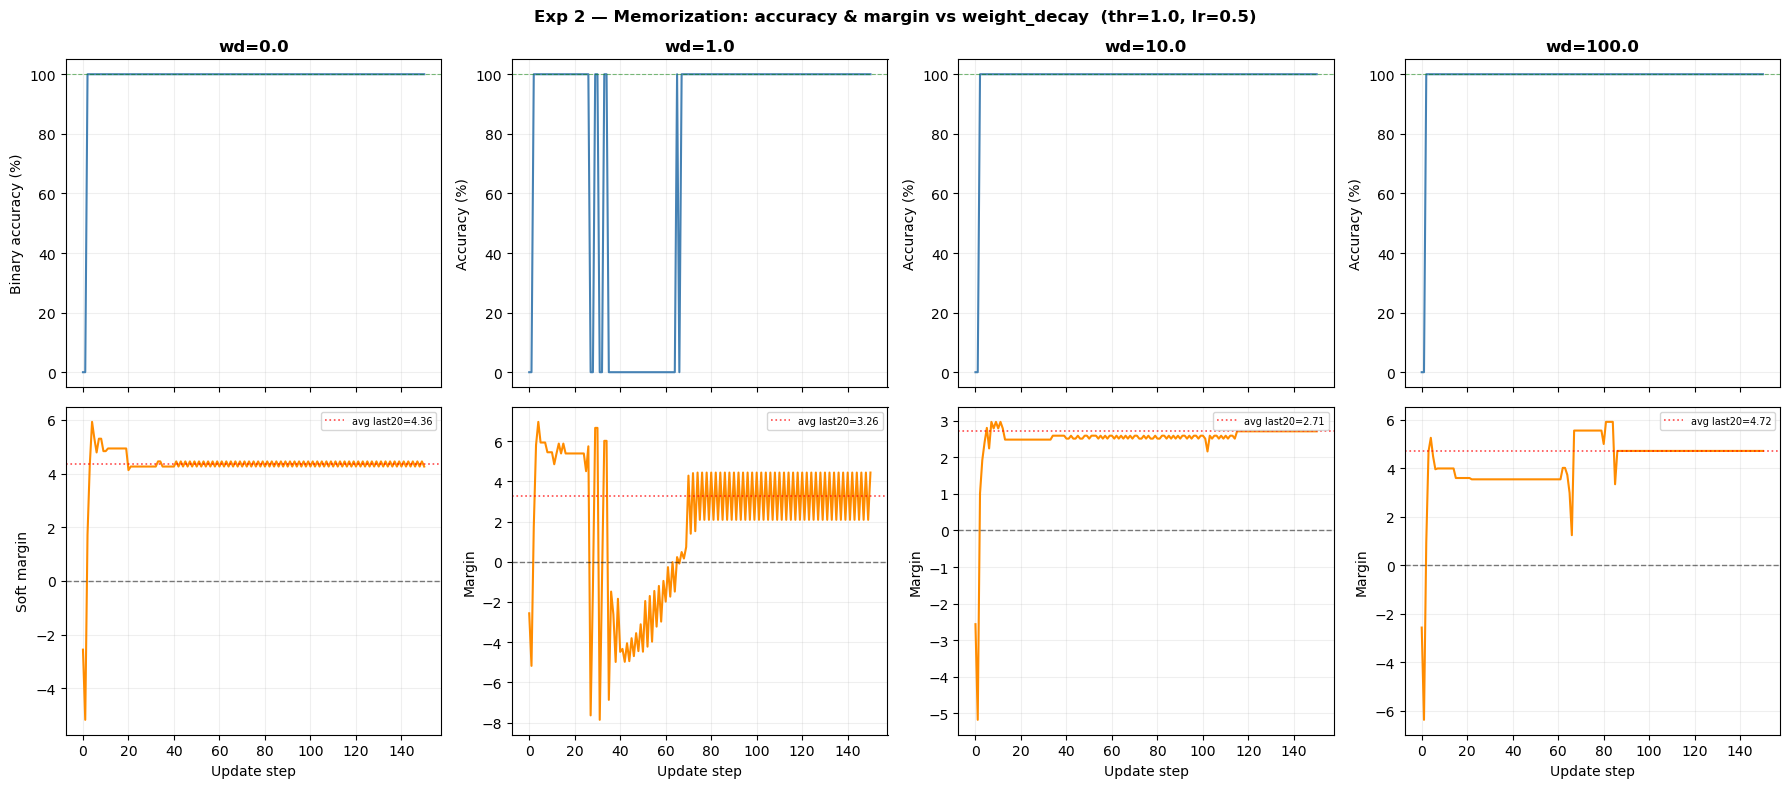

In [9]:
fig, axes = plt.subplots(2, len(WD_VALUES), figsize=(4.5 * len(WD_VALUES), 8), sharex=True)

for ci, wd in enumerate(WD_VALUES):
    r = mem_results[wd]
    steps = list(range(len(r["accs"])))

    # Row 0: binary accuracy
    ax = axes[0, ci]
    ax.plot(steps, r["accs"], color="steelblue", lw=1.5)
    ax.axhline(100, color="green", lw=0.8, ls="--", alpha=0.5)
    ax.set_ylim(-5, 105); ax.set_title(f"wd={wd}", fontweight="bold")
    ax.set_ylabel("Accuracy (%)"); ax.grid(True, alpha=0.2)

    # Row 1: soft margin
    ax = axes[1, ci]
    ax.plot(steps, r["margins"], color="darkorange", lw=1.5)
    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax.set_ylabel("Margin"); ax.set_xlabel("Update step")
    ax.grid(True, alpha=0.2)
    # Shade mean of last 20 steps
    mean_m = np.mean(r["margins"][-20:])
    ax.axhline(mean_m, color="red", lw=1.2, ls=":", alpha=0.7,
               label=f"avg last20={mean_m:.2f}")
    ax.legend(fontsize=7)

axes[0, 0].set_ylabel("Binary accuracy (%)")
axes[1, 0].set_ylabel("Soft margin")
fig.suptitle("Exp 2 — Memorization: accuracy & margin vs weight_decay  (thr=1.0, lr=0.5)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp2_memorization.png", dpi=120)
plt.show()

---
## Experiment 3 — Catastrophic forgetting vs weight decay

Train on image A for `N_PHASE_A` steps, then switch to image B for `N_PHASE_B` steps.  
Track the **soft margin** on both A and B throughout.

In [10]:
forget_results = {}   # wd → {steps, mg_A, mg_B}

for wd in WD_VALUES:
    st, orch = build_model(seed=0, weight_decay=wd)
    opt, opt_st = build_opt(orch)
    rng = jax.random.PRNGKey(7)
    steps, mg_A, mg_B = [], [], []

    for global_step in range(N_PHASE_A + N_PHASE_B + 1):
        in_B = (global_step > N_PHASE_A)
        x_tr, y_tr = (x_B1, y_B1) if in_B else (x_A1, y_A1)

        for xd, yd, lst in [(x_A1, y_A1, mg_A), (x_B1, y_B1, mg_B)]:
            s0 = st.init(xd, yd)
            rng, dr = jax.random.split(rng)
            sf, _ = run_dynamics(orch, s0, dr)
            _, mg, rng = get_soft_scores(orch, sf, yd, rng)
            lst.append(mg)

        steps.append(global_step)
        if global_step < N_PHASE_A + N_PHASE_B:
            s0 = st.init(x_tr, y_tr)
            rng, dr = jax.random.split(rng)
            sf, _ = run_dynamics(orch, s0, dr)
            orch, opt_st, rng = update_weights(orch, sf, rng, opt, opt_st)

    forget_results[wd] = {"steps": steps, "mg_A": mg_A, "mg_B": mg_B}
    peak_A = max(mg_A[:N_PHASE_A + 1])
    end_A  = np.mean(mg_A[-10:])
    end_B  = np.mean(mg_B[-10:])
    print(f"wd={wd:<6}  A peak_margin={peak_A:.2f}  A avg_last10={end_A:.2f}  B avg_last10={end_B:.2f}")

print("\nForgetting sweep done ✓")

wd=0.0     A peak_margin=5.93  A avg_last10=4.36  B avg_last10=4.36
wd=1.0     A peak_margin=6.96  A avg_last10=2.95  B avg_last10=2.40
wd=10.0    A peak_margin=2.97  A avg_last10=1.34  B avg_last10=1.39
wd=100.0   A peak_margin=5.26  A avg_last10=4.36  B avg_last10=4.91

Forgetting sweep done ✓


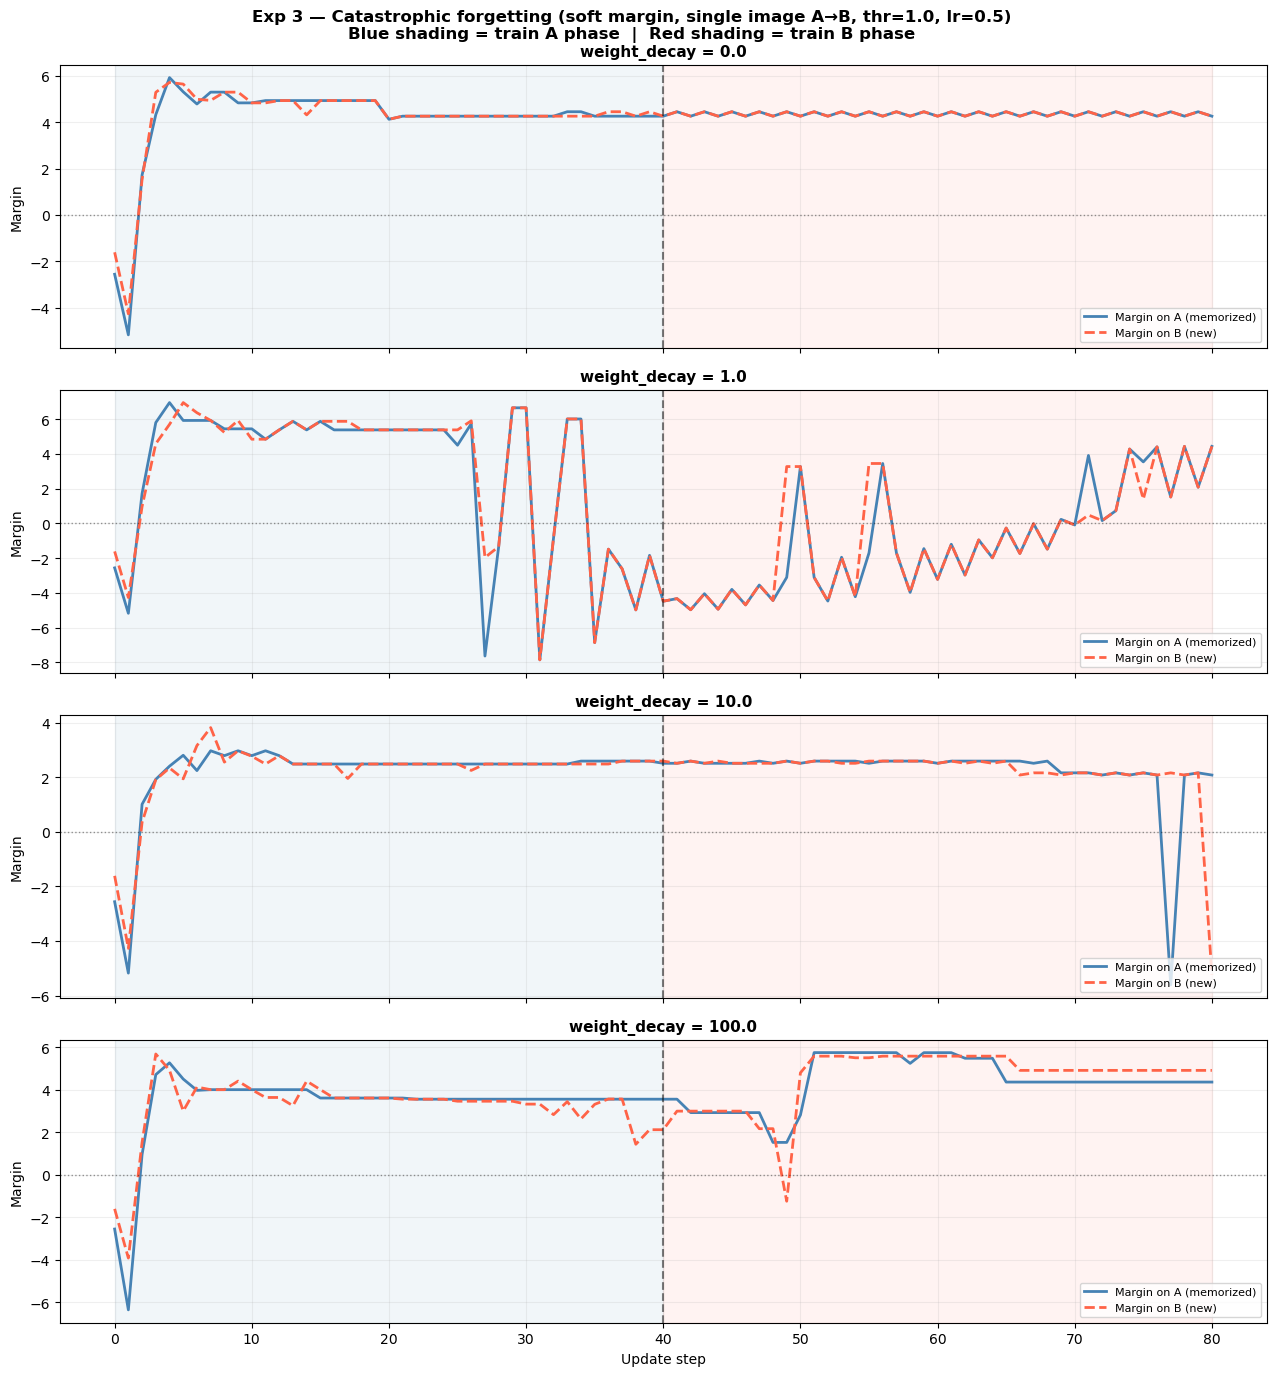

In [11]:
fig, axes = plt.subplots(len(WD_VALUES), 1,
                          figsize=(13, 3.5 * len(WD_VALUES)), sharex=True)

for ax, wd in zip(axes, WD_VALUES):
    r = forget_results[wd]
    ax.plot(r["steps"], r["mg_A"], color="steelblue", lw=2, label="Margin on A (memorized)")
    ax.plot(r["steps"], r["mg_B"], color="tomato",    lw=2, label="Margin on B (new)", ls="--")
    ax.axvspan(0, N_PHASE_A, alpha=0.07, color="steelblue")
    ax.axvspan(N_PHASE_A, r["steps"][-1], alpha=0.07, color="tomato")
    ax.axvline(N_PHASE_A, color="black", lw=1.5, ls="--", alpha=0.5)
    ax.axhline(0, color="black", lw=1, ls=":", alpha=0.4)
    ax.set_ylabel("Margin"); ax.grid(True, alpha=0.2)
    ax.set_title(f"weight_decay = {wd}", fontweight="bold", fontsize=11)
    ax.legend(fontsize=8, loc="lower right")

axes[-1].set_xlabel("Update step")
fig.suptitle(
    "Exp 3 — Catastrophic forgetting (soft margin, single image A→B, thr=1.0, lr=0.5)\n"
    "Blue shading = train A phase  |  Red shading = train B phase",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp3_forgetting.png", dpi=120)
plt.show()

---
## Experiment 4 — Equilibrium norm vs weight decay

The theoretical prediction is:  
$$\|J\|_{eq} \approx \frac{\text{Hebbian signal}}{\text{weight\_decay}}$$

i.e., `‖J_conv‖` at convergence should scale as `1/wd`.  
Let's verify this empirically.

Equilibrium ‖J_conv‖ estimates:
  wd=0.0     ‖J_conv‖ ≈ 83469.1
  wd=1.0     ‖J_conv‖ ≈ 35375.9
  wd=10.0    ‖J_conv‖ ≈ 3892.9
  wd=100.0   ‖J_conv‖ ≈ 120.4


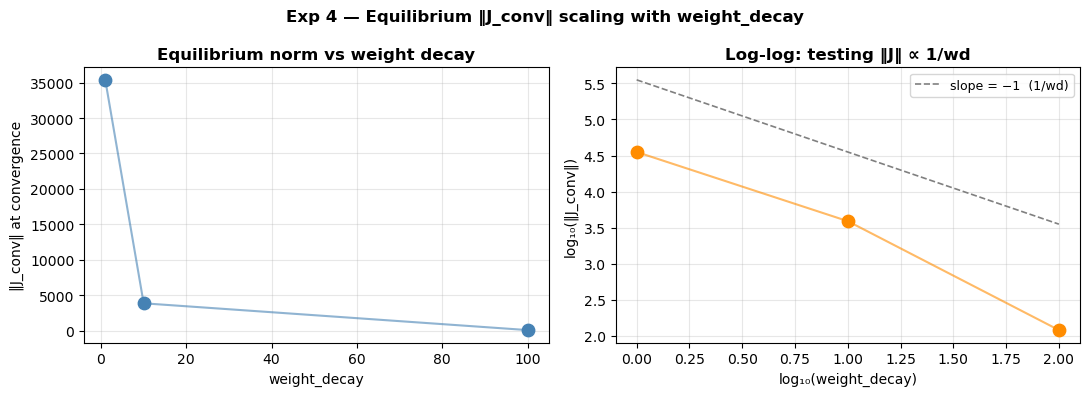

In [12]:
# Use the last 20 steps of norm_results as the equilibrium estimate
eq_norms = {wd: np.mean([n["j_conv"] for n in norm_results[wd][-20:]])
            for wd in WD_VALUES}

print("Equilibrium ‖J_conv‖ estimates:")
for wd, norm in eq_norms.items():
    print(f"  wd={wd:<6}  ‖J_conv‖ ≈ {norm:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: norm vs wd
wds_nonzero = [wd for wd in WD_VALUES if wd > 0]
norms_nz    = [eq_norms[wd] for wd in wds_nonzero]
axes[0].scatter(wds_nonzero, norms_nz, s=80, zorder=3, color="steelblue")
axes[0].plot(wds_nonzero, norms_nz, lw=1.5, color="steelblue", alpha=0.6)
axes[0].set_xlabel("weight_decay"); axes[0].set_ylabel("‖J_conv‖ at convergence")
axes[0].set_title("Equilibrium norm vs weight decay", fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Right: log-log to check 1/wd scaling
axes[1].scatter(np.log10(wds_nonzero), np.log10(norms_nz), s=80, zorder=3, color="darkorange")
axes[1].plot(np.log10(wds_nonzero), np.log10(norms_nz), lw=1.5, color="darkorange", alpha=0.6)
# Reference line with slope -1
x_ref = np.array(np.log10(wds_nonzero))
y_ref = -x_ref + (np.log10(norms_nz[0]) + wds_nonzero[0])
axes[1].plot(x_ref, y_ref, ls="--", color="gray", lw=1.2, label="slope = −1  (1/wd)")
axes[1].set_xlabel("log₁₀(weight_decay)"); axes[1].set_ylabel("log₁₀(‖J_conv‖)")
axes[1].set_title("Log-log: testing ‖J‖ ∝ 1/wd", fontweight="bold")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

fig.suptitle("Exp 4 — Equilibrium ‖J_conv‖ scaling with weight_decay",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp4_equilibrium.png", dpi=120)
plt.show()

---
## Summary

*Fill in after running.*